# 1. Introdução
A manipulação de datas e horários é uma tarefa comum em análise de dados. Python oferece várias bibliotecas para lidar com isso de forma eficiente. Vamos explorar as principais funcionalidades e boas práticas.

In [1]:
# Importando as bibliotecas necessárias
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Trabalhando com datetime
O módulo datetime é parte da biblioteca padrão do Python e oferece classes para manipulação de datas e horários.

In [2]:
# Criando objetos datetime
data_atual = datetime.datetime.now()
print(f"Data e hora atual: {data_atual}")

# Criando uma data específica
data_especifica = datetime.datetime(2023, 12, 31, 23, 59, 59)
print(f"Data específica: {data_especifica}")

# Extraindo componentes
print(f"Ano: {data_atual.year}")
print(f"Mês: {data_atual.month}")
print(f"Dia: {data_atual.day}")
print(f"Hora: {data_atual.hour}")
print(f"Minuto: {data_atual.minute}")
print(f"Segundo: {data_atual.second}")

Data e hora atual: 2025-11-10 16:26:36.856339
Data específica: 2023-12-31 23:59:59
Ano: 2025
Mês: 11
Dia: 10
Hora: 16
Minuto: 26
Segundo: 36


In [3]:
datetime.datetime.now().hour

16

# 3. Operações com Datas
Podemos realizar várias operações com datas, como adicionar ou subtrair períodos, calcular diferenças, etc.

In [4]:
# Adicionando dias
data_futura = data_atual + datetime.timedelta(days=7)
print(f"Data daqui a 7 dias: {data_futura}")

# Subtraindo horas
data_passada = data_atual - datetime.timedelta(hours=24)
print(f"Data 24 horas atrás: {data_passada}")

# Calculando diferença entre datas
diferenca = data_futura - data_atual
print(f"Diferença em dias: {diferenca.days}")
print(f"Diferença em segundos: {diferenca.total_seconds()}")

Data daqui a 7 dias: 2025-11-17 16:26:36.856339
Data 24 horas atrás: 2025-11-09 16:26:36.856339
Diferença em dias: 7
Diferença em segundos: 604800.0


# 4. Formatação de Datas
A formatação de datas é essencial para exibição e conversão entre diferentes formatos.

In [5]:
# Formatando datas
print(f"Formato padrão: {data_atual}")
print(f"Formato personalizado: {data_atual.strftime('%d/%m/%Y %H:%M:%S')}")
print(f"Apenas data: {data_atual.strftime('%d/%m/%Y')}")
print(f"Apenas hora: {data_atual.strftime('%H:%M:%S')}")

# Convertendo string para datetime
data_string = "31/12/2023 23:59:59"
data_convertida = datetime.datetime.strptime(data_string, '%d/%m/%Y %H:%M:%S')
print(f"Data convertida: {data_convertida}")

Formato padrão: 2025-11-10 16:26:36.856339
Formato personalizado: 10/11/2025 16:26:36
Apenas data: 10/11/2025
Apenas hora: 16:26:36
Data convertida: 2023-12-31 23:59:59


In [6]:
data_new_format = 'ano: 2025, mes: 05, dia: 10'
data_convertida_padronizada = datetime.datetime.strptime(data_new_format, 'ano: %Y, mes: %m, dia: %d')
print(f"Data convertida: {data_convertida_padronizada}")

Data convertida: 2025-05-10 00:00:00


# 5. Trabalhando com pandas
O pandas oferece funcionalidades mais avançadas para manipulação de datas em DataFrames.

In [7]:
# Criando um DataFrame com datas
datas = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
df = pd.DataFrame({'data': datas})
print("Primeiras 5 linhas do DataFrame:")
print(df.head())

# Extraindo componentes da data
df['ano'] = df['data'].dt.year
df['mes'] = df['data'].dt.month
df['dia'] = df['data'].dt.day
df['dia_semana'] = df['data'].dt.day_name()
print("\nDataFrame com componentes extraídos:")
print(df.head())

Primeiras 5 linhas do DataFrame:
        data
0 2023-01-01
1 2023-01-02
2 2023-01-03
3 2023-01-04
4 2023-01-05

DataFrame com componentes extraídos:
        data   ano  mes  dia dia_semana
0 2023-01-01  2023    1    1     Sunday
1 2023-01-02  2023    1    2     Monday
2 2023-01-03  2023    1    3    Tuesday
3 2023-01-04  2023    1    4  Wednesday
4 2023-01-05  2023    1    5   Thursday


# 6. Operações Avançadas com pandas
Vamos explorar algumas operações mais avançadas com datas no pandas.

In [8]:
# Agrupando por mês
df_mensal = df.groupby(df['data'].dt.month).size().reset_index(name='contagem')
print("Contagem de dias por mês:")
print(df_mensal)

# Criando uma série temporal
np.random.seed(42)
df['valor'] = np.random.randn(len(df))
df.set_index('data', inplace=True)

# Resampling para frequência mensal
df_mensal = df['valor'].resample('M').mean()
print("\nMédia mensal dos valores:")
print(df_mensal)

Contagem de dias por mês:
    data  contagem
0      1        31
1      2        28
2      3        31
3      4        30
4      5        31
5      6        30
6      7        31
7      8        31
8      9        30
9     10        31
10    11        30
11    12        31

Média mensal dos valores:
data
2023-01-31   -0.201488
2023-02-28   -0.143168
2023-03-31    0.043938
2023-04-30   -0.020252
2023-05-31   -0.083815
2023-06-30    0.291292
2023-07-31    0.098341
2023-08-31   -0.021537
2023-09-30   -0.091070
2023-10-31    0.064996
2023-11-30    0.232571
2023-12-31   -0.053246
Freq: M, Name: valor, dtype: float64


# 7. Visualização de Dados Temporais
Vamos criar algumas visualizações para entender melhor os dados temporais.

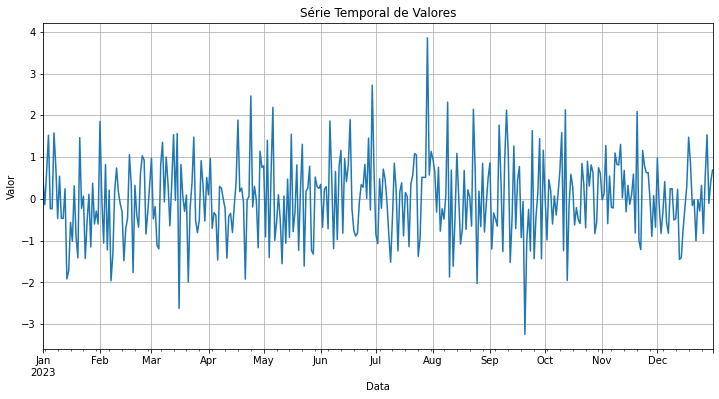

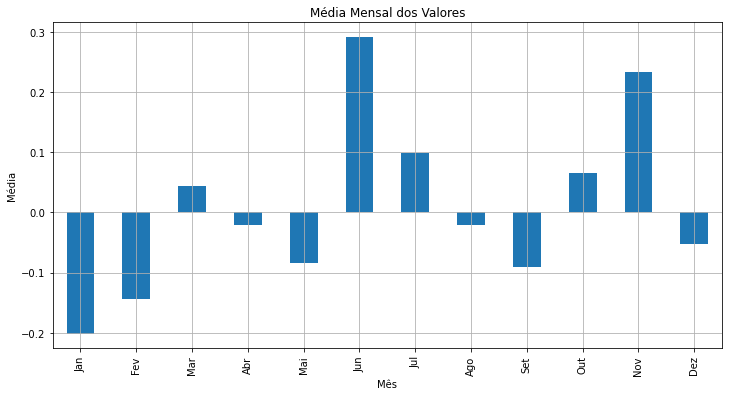

In [9]:
# Criando um gráfico de linha
plt.figure(figsize=(12, 6))
df['valor'].plot()
plt.title('Série Temporal de Valores')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.grid(True)
plt.show()

# rename meses para Jan, Fev, Mar, Abr, etc
# Renomeando os meses para abreviações em português
meses_abrev = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}

# Criando uma cópia do df_mensal com os nomes dos meses abreviados
df_mensal_renamed = df_mensal.copy()
df_mensal_renamed.index = df_mensal_renamed.index.strftime('%Y-%m-%d')
df_mensal_renamed.index = [meses_abrev[int(data.split('-')[1])] for data in df_mensal_renamed.index.astype(str)]


# Criando um gráfico de barras para a contagem mensal
plt.figure(figsize=(12, 6))
df_mensal_renamed.plot(kind='bar')
plt.title('Média Mensal dos Valores')
plt.xlabel('Mês')
plt.ylabel('Média')
plt.grid(True)
plt.show()